# 09 — OE Superpixel Inversion (SLIC + PCA/kNN)

Demonstrates the SLIC superpixel inversion pipeline from `superpixel_engine.py`:

1. **Segment** the image into spectrally coherent superpixels (SLIC)
2. **Invert** the mean spectrum of each superpixel with OE
3. **Back-interpolate** to full pixel resolution using PCA + kNN IDW

***Example: North Sea EnMAP***

| Step | Key parameter | Paper default |
|---|---|---|
| SLIC `n_segments` | target superpixel count | ~1% of pixels |
| SLIC `compactness` | shape vs spectral fidelity | 0.1 (low → follow edges) |
| SLIC `sigma` | pre-smoothing | 2.0 |
| PCA `n_components` | spectral embedding dims | 6 |
| kNN `k` | neighbours for IDW | 4 |

Reference: Adams et al. (2021), *Remote Sensing of Environment*.

In [1]:
import os
import time
import numpy as np
import xarray as xr
import lmfit
import matplotlib.pyplot as plt
import jax.numpy as jnp
import cmocean.cm as cm
from skimage.segmentation import mark_boundaries
from xcube.core.store import new_data_store

from bio_optics.inversion import oe_engine, dask_oe_engine, superpixel_engine
from bio_optics.water.reflectance import bi_jax

In [2]:
def find_closest(arr: np.array, val: int):  
  """ 
  Find the closest value to a number in an array.
  
  :param arr:  an array or list of numbers
  :param val:  the number  
  :return:     the closest value and its index in arr
  """
  arr = np.asarray(arr)
  idx = (np.abs(arr - val)).argmin()
  
  return arr[idx], idx

# Load data

## Same Sentinel-2 Wadden Sea scene as NB07b.

In [2]:
dataset = xr.open_dataset(os.path.join(os.getcwd(), 'example_data/S2L2A_example.nc'))

wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865])
band_vars   = list(dataset.data_vars)[1:]

ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(ref_band.dims)
spatial_coords    = {d: dataset[d].values for d in spatial_dim_names if d in dataset.coords}

Rrs_image = np.stack(
    [dataset.isel(time=1)[v].values for v in band_vars], axis=-1
) / np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_obs} bands)')

Rrs_image: (267, 449, 8)  (119883 pixels, 8 bands)


## EnMAP Wadden Sea

In [47]:
root = 'D:\Documents\projects\EnsAD\EnMAP\L2A_Water\\v010502\Waddensea\zarr\\'
zarrList = os.listdir(root)
dateList = ['20240530', '20240626', '20240727', '20240819', '20240831', '20241112']
## goodExamples = {'20240626': ['_005_', '_006_', '_007_'], '20240727': ['_001_', '_002_', '_003_'], 
##    '20240819':['_004_', '_005_', '_007_' ], '20240831':['_001_', '_002_'], '20241112'}
zarrList = [z for z in zarrList if dateList[4] in z]
print(len(zarrList))
zarrFname = zarrList[1]
print(zarrFname)
local = new_data_store("file", root=root)
dr = local.open_data(zarrFname)
wl = dr.band.values
ind665_, ind665 = find_closest(wl, 665)
ind560_, ind560 = find_closest(wl, 560)
ind440_, ind440 = find_closest(wl, 440)

flags2D = dr.quality_classes.values[:,:]

# wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865]) # selection
ID = wl < 850.
wavelengths = wl[ID]
band_vars = []
for w in wavelengths:
    ind_, ind = find_closest(wl, w)
    band_vars.append(ind)

# print(band_vars)

# ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(dr.band_data.isel(band=0).dims)
spatial_coords    = {d: dr[d].values for d in spatial_dim_names if d in dr.coords}

Rrs_image = np.stack(
    [dr.band_data.isel(band=v).values for v in band_vars], axis=-1
) #/ np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
n_pixels_valid = np.sum(np.sum(np.logical_not(np.isnan(Rrs_image)), axis=-1)>0)
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_pixels_valid} valid water pixels, {n_obs} bands)')
# dataset = xr.open_dataset(os.path.join(os.getcwd(), 'example_data/S2L2A_example.nc'))

# wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865])
# band_vars   = list(dataset.data_vars)[1:]

# ref_band          = dataset.isel(time=1)[band_vars[0]]
# spatial_dim_names = list(ref_band.dims)
# spatial_coords    = {d: dataset[d].values for d in spatial_dim_names if d in dataset.coords}

# Rrs_image = np.stack(
#     [dataset.isel(time=1)[v].values for v in band_vars], axis=-1
# ) / np.pi

# n_rows, n_cols, n_obs = Rrs_image.shape
# n_pixels = n_rows * n_cols
# print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_obs} bands)')

2
enmapZarr_ENMAP01-____L2A-DT0000090299_20240831T112133Z_002_V010502_20250116T085503Z.zarr
Rrs_image: (930, 1648, 73)  (1532640 pixels, 286874 valid water pixels, 73 bands)


## EnMAP North Sea

In [11]:
root = 'D:\Documents\projects\EnsAD\EnMAP\L2A_Water\\v010502\\NorthSea\zarr\\'
zarrList = os.listdir(root)
dateList = ['20230806', '20230809', '20230815']
## goodExamples = {'20230806':[], '20230809':['_001_','_002_','_003_'], '20230815':['_001', '_002_', '_003_']}
zarrList = [z for z in zarrList if dateList[2] in z]
print(len(zarrList))
zarrFname = zarrList[1]
print(zarrFname)
local = new_data_store("file", root=root)
dr = local.open_data(zarrFname)
wl = dr.band.values
ind665_, ind665 = find_closest(wl, 665)
ind560_, ind560 = find_closest(wl, 560)
ind440_, ind440 = find_closest(wl, 440)

print(ind440, ind560, ind665)

flags2D = dr.quality_classes.values[:,:]


# wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865]) # selection
ID = wl < 850.
wavelengths = wl[ID]
band_vars = []
for w in wavelengths:
    ind_, ind = find_closest(wl, w)
    band_vars.append(ind)

# print(band_vars)

# ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(dr.band_data.isel(band=0).dims)
spatial_coords    = {d: dr[d].values for d in spatial_dim_names if d in dr.coords}

Rrs_image = np.stack(
    [dr.band_data.isel(band=v).values for v in band_vars], axis=-1
) #/ np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_obs} bands)')

3
enmapZarr_ENMAP01-____L2A-DT0000035300_20230815T111709Z_002_V010506_20260326T164446Z.zarr
4 29 47
Rrs_image: (917, 1572, 73)  (1441524 pixels, 73 bands)


## Further steps  
- destriping ?! Seems necessary, otherwise no clusters are formed, if the scene is pure water!

47 29 4
NDWI [561.112 871.683]


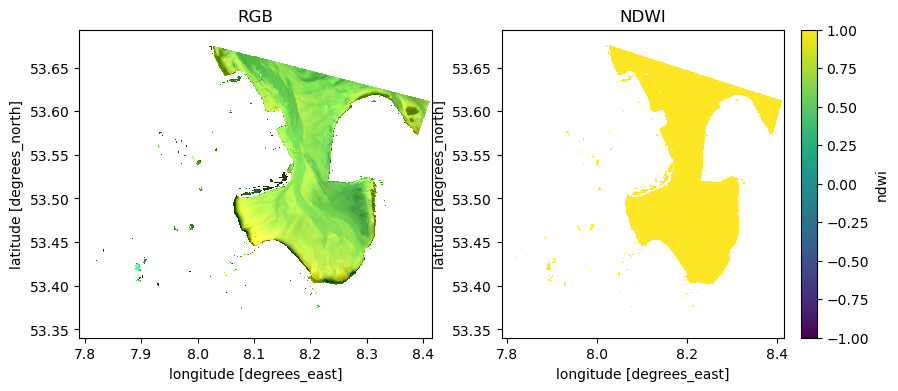

In [48]:
# dr.band_data.isel(band=10).plot()
print(ind665, ind560, ind440)
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
dr.band_data.isel(band = [ind665, ind560, ind440]).plot.imshow(ax=ax[0], robust=True)
ax[0].set_title('RGB')

Rrs_ndwi = dr.band_data.isel(band=[29,75]).values #dr.band_data.isel(band=[29, 75]).values
print('NDWI', wl[[29, 75]])
ndwi = (Rrs_ndwi[0,:,:] - Rrs_ndwi[1,:,:]) / (Rrs_ndwi[0, :,:] + Rrs_ndwi[1, :,:])
dr = dr.assign(ndwi=(['y', 'x'], ndwi))
dr.ndwi.plot(ax=ax[1], vmin=-1, vmax=1)
ax[1].set_title('NDWI')
plt.show()

## Configuration Bi & Hieronymi

In [49]:
regionName='NorthSea'
sensor = 'EnMAP'
versionAC = 'EnMAPWaterv1.5.2'
dataType = 'EnMAPTile' # 'Sim'
## CAUTION: only Standardv2 is implemented here!! ##
AlgaeGroupType = 'Standardv2' #'Standardv2' # 'Standardv3' # 'NSSummerBloomsv3' Standardv2, 'HEREONgold'

# maxWavelength= 750.
maxWavelength = 850.

In [6]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=True)
    params.add('C_ism', value=0, min=0, max=100, vary=True)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.002, vary=False)  # Diatoms 0.0058; HEREONweb: 0.002
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green 0.007, HEREONweb: 0.007
    params.add('b_ratio_C_2', value=0.002, vary=False)  # cryptophyte 0.0042, HEREONweb: 0.002
    params.add('b_ratio_C_3', value=0.003, vary=False)  # cyano blue 0.0082, HEREONweb: 0.003
    params.add('b_ratio_C_4', value=0.003, vary=False)  # cyano red 0.001, HEREONweb: 0.003
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    elif AlgaeGroupType == 'HEREONgold':
        params.add('b_ratio_C_5', value=0.002, vary=False)
    else:
        params.add('b_ratio_C_5', value=0.0129,
                   vary=False)  # coccolithophores 0.0129, , HEREONweb: 0.007, Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates 0.0209, HEREONweb: not available
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.007,
                   vary=False)  # case-1 0.0109, HEREONweb: 0.007, Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=False)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.020, min=0.018, max=0.022, vary=True) # Helsinki: 0.018 -0.022; test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A_phy', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=False, vary=False) # value=True
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params


def setDictValues(value, vmin, vmax):
    dd = {'value': value, 'min': vmin, 'max': vmax}
    return dd

In [7]:
## North Sea
processingDict = {
    'C_0': setDictValues(0.1,0,200), #brown
    # 'C_1': setDictValues(0.1,0,200), #green
    'C_2': setDictValues(0.1,0,200), # crypto
    # 'C_3': setDictValues(0,0,200), # cyano blue
    # 'C_4': setDictValues(0,0,100), # cyano red
    #'C_5': setDictValues(0,0,200), # coccolith.
    'C_6': setDictValues(0.1,0,200), # dinoflagellate
    'C_Y': setDictValues(0.1,0,1),
    'C_ism': setDictValues(0.1,0,150),
    'L_fl_lambda0': setDictValues(0,0,0.2),
    # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
    # 'L_fl_phycocyanin': setDictValues(0,0,0.2),
    # 'offset': setDictValues(0, -0.1, 0.1)
}

In [8]:
fit_config = {
    'C_0':     dict(vary=True, value=1,  sigma_a=1.0, log=True),
    # 'C_1':     dict(vary=True, value=1,  sigma_a=1.0, log=True),
    'C_2':     dict(vary=True, value=1,  sigma_a=1.0, log=True),
    'C_6':     dict(vary=True, value=1,  sigma_a=1.0, log=True),
    'C_Y':     dict(vary=True, value=1,  sigma_a=1.0, log=True),
    'C_ism':   dict(vary=True, value=1,  sigma_a=1.0, log=True),
    'L_fl_lambda0':  dict(vary=True,  value=0.01,  sigma_a=0.1, log=False),
    'S_cdom': dict(value=0.020, min=0.018, max=0.022, sigma_a=0.002, log=False, vary=True),
    # 'offset': dict(vary=True, value=0, sigma_a=0.2, log=False)
}

noise     = 0.01 # 0.0031
n_iter    = 30 #15
tile_size = 4096

# PARAM_META = {
#     'zB':      ('Depth z_B',          'm',     cm.deep),
#     'f_mix_0': ('Mix logit (sand)',    'logit', 'RdYlGn'),
# }

# --- build lmfit Parameters --------------------------------------------------
paramDict = processingDict
params = set_default_parameters(AlgaeGroupType)
params = set_parameters_byDict(paramDict, params)


sigma_a    = {n: c['sigma_a'] for n, c in fit_config.items() if c['vary']}
log_params = [n for n, c in fit_config.items() if c['vary'] and c['log']]


In [9]:
# --- precompute --------------------------
pre_base     = bi_jax.precompute(wavelengths)
# R_b_full     = np.array(pre_base['R_b_i'])
# R_b_selected = np.zeros_like(R_b_full)
# for dst, src in enumerate(bottom_types):
#     R_b_selected[:, dst] = R_b_full[:, src]
pre = {**pre_base}

all_names = list(params.keys())
f_vec     = bi_jax.make_forward_vec(all_names, pre)
setup     = oe_engine.build_inversion(params, f_vec, sigma_a, log_params=log_params)

print('Free parameters:', setup.fit_names)
print('log_params:',      log_params)

Free parameters: ['C_0', 'C_2', 'C_6', 'C_Y', 'C_ism', 'L_fl_lambda0', 'S_cdom']
log_params: ['C_0', 'C_2', 'C_6', 'C_Y', 'C_ism']


## Step 1 — SLIC segmentation

`compactness=0.1` allows superpixel shapes to follow natural spectral edges  
(water eddies, depth gradients) rather than enforcing compact blobs.  
`sigma=2.0` reduces the impact of per-pixel spectral noise on cluster assignment.

In [10]:
# SLIC parameters (paper defaults)
n_segments  = 1200   # ~1% of 119 883 pixels
compactness = 0.1 
slic_sigma  = 2.0

t0     = time.perf_counter()
labels = superpixel_engine.segment_image(
    Rrs_image, n_segments=n_segments,
    compactness=compactness, sigma=slic_sigma,
)
t_seg  = time.perf_counter() - t0

n_segs_actual = len(np.unique(labels))
print(f'Requested {n_segments} segments → got {n_segs_actual}  ({t_seg:.2f} s)')
print(f'Mean pixels per segment: {n_pixels / n_segs_actual:.0f}')

Requested 1200 segments → got 1125  (21.00 s)
Mean pixels per segment: 1362


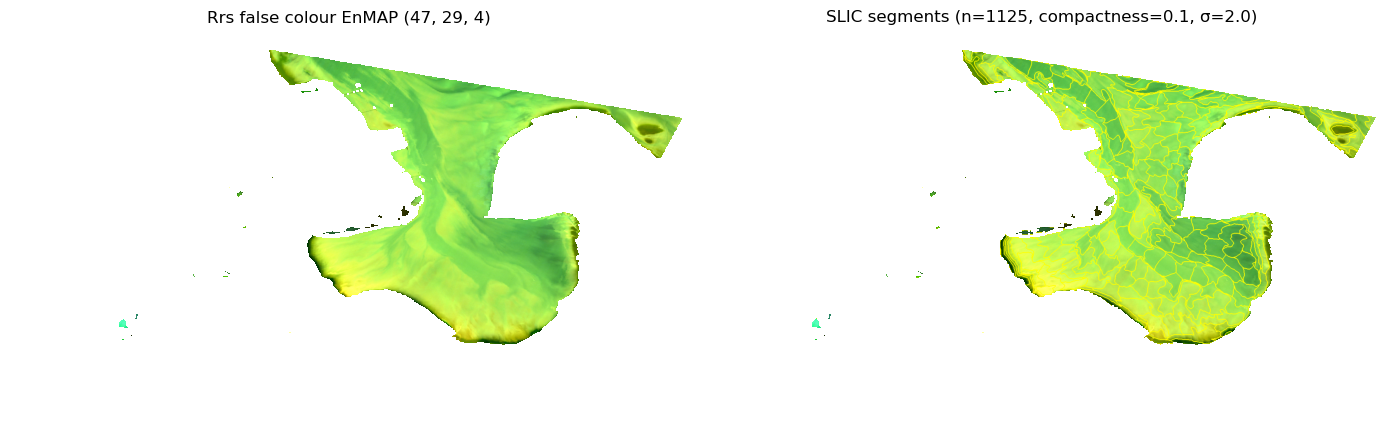

In [11]:
# False-colour RGB for overlay
rgb_bands = [ind665, ind560, ind440]   # B04, B03, B02 → R, G, B
rgb = Rrs_image[..., rgb_bands]
rgb = (rgb - np.nanpercentile(rgb, 2)) / (np.nanpercentile(rgb, 98) - np.nanpercentile(rgb, 2))
rgb = np.clip(rgb, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(rgb, origin='upper')
BandStr = str(ind665) + ', ' + str(ind560) + ', ' + str(ind440)
axes[0].set_title('Rrs false colour EnMAP ('+BandStr +')')
axes[0].axis('off')

# mark_boundaries draws segment outlines on the image
img_boundaries = mark_boundaries(rgb, labels, color=(1, 1, 0), mode='thick')
axes[1].imshow(img_boundaries, origin='upper')
axes[1].set_title(f'SLIC segments (n={n_segs_actual}, compactness={compactness}, σ={slic_sigma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 2 — Aggregate superpixel mean spectra

sp_spectra shape: (1125, 73)
valid sp_spectra: 313
Pixel counts (in valid superpixel) — min: 1  median: 930  max: 2955


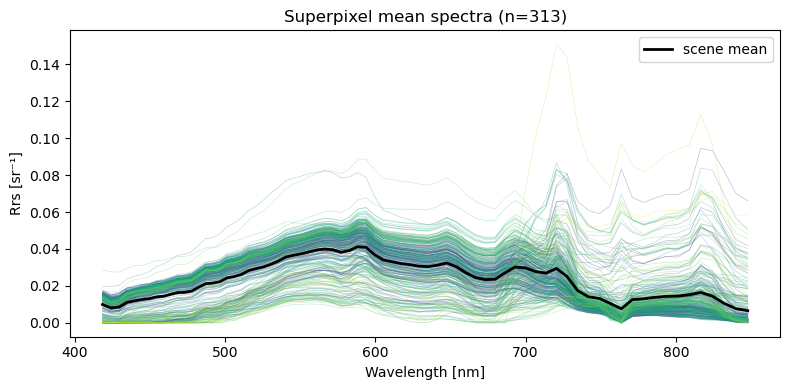

In [45]:
sp_spectra, sp_counts = superpixel_engine.aggregate_superpixels(Rrs_image, labels)

valid = np.where(np.sum(np.logical_not(np.isnan(sp_spectra)), axis=1)>0)[0]
print(f'sp_spectra shape: {sp_spectra.shape}')
print(f'valid sp_spectra: {len(valid)}')
print(f'Pixel counts (in valid superpixel) — min: {sp_counts[valid].min()}  median: {np.nanmedian(sp_counts[valid]):.0f}  max: {sp_counts[valid].max()}')

fig, ax = plt.subplots(figsize=(8, 4))
cvals = np.linspace(0, 1, n_segs_actual)
n_segs_actual_noNaN = 0
for i in range(n_segs_actual):
    if np.sum(np.logical_not(np.isnan(sp_spectra[i])))>0:
        n_segs_actual_noNaN +=1
        ax.plot(wavelengths, sp_spectra[i], color=plt.cm.viridis(cvals[i]), alpha=0.3, lw=0.5)
ax.plot(wavelengths, np.nanmean(sp_spectra, axis=0), 'k-', lw=2, label='scene mean')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr⁻¹]')
ax.set_title(f'Superpixel mean spectra (n={n_segs_actual_noNaN})')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
## write mean spectra to file
import pandas as pd
valid = np.where(np.sum(np.logical_not(np.isnan(sp_spectra)), axis=1)>0)[0]
outdf = pd.DataFrame(sp_spectra[valid,:], columns=[str(a) for a in wavelengths])
outpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\\"
#zarrFname: enmapZarr_ENMAP01-____L2A-DT0000090299_20240831T112133Z_002_V010502_20250116T085503Z.zarr
outfile = zarrFname.split('enmapZarr_ENMAP01-____L2A-')[1].split('.zarr')[0]
outdf.to_csv(outpath + "EnMAPsuperpixel_"+outfile +'.txt',  sep='\t', header=True, index=False)

## Step 3 — OE inversion of superpixel mean spectra

Each superpixel is inverted independently using the same `setup`.  
The noise passed here is the **original pixel noise** — the chi2 values will be  
smaller than for per-pixel inversion because mean spectra are smoother.  
The calibrated chi2 = chi2_raw × N_pixels accounts for this.
  
**TODO**:  
Could be restricted to the valid superpixels only!  
Is there a difference in processing results or timing?

In [50]:
## Original ##
t0 = time.perf_counter()
sp_results = superpixel_engine.invert_superpixels(
    sp_spectra, sp_counts, setup, noise,
    n_iter=n_iter, tile_size=tile_size, store_y_hat=True
)
t_sp = time.perf_counter() - t0

print(f'Superpixel inversion: {n_segs_actual} segments in {t_sp:.2f} s')
print(f'Speedup vs full image (~{n_pixels} px): {n_pixels / n_segs_actual:.0f}× fewer inversions')

Superpixel inversion: 1125 segments in 7.43 s
Speedup vs full image (~1532640 px): 1362× fewer inversions


In [51]:
## Restricted to valid pixels ## 
t0 = time.perf_counter()
sp_results = superpixel_engine.invert_superpixels(
    sp_spectra[valid,:], sp_counts[valid], setup, noise,
    n_iter=n_iter, tile_size=tile_size, store_y_hat=True
)
t_sp = time.perf_counter() - t0

print(f'Superpixel inversion: {n_segs_actual_noNaN} segments in {t_sp:.2f} s')
print(f'Speedup vs full image (~{n_pixels_valid} px): {n_pixels_valid / n_segs_actual_noNaN:.0f}× fewer inversions')

Superpixel inversion: 313 segments in 54.00 s
Speedup vs full image (~286874 px): 917× fewer inversions


In [45]:
sp_results

{'x_hat': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(1125, 7)),
 'sigma': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(1125, 7)),
 'A_diag': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(1125, 7)),
 'chi2': array([nan, nan, nan, ..., nan, nan, nan], shape=(1125,))

In [33]:
## read full inversion old way
import pandas as pd
inpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\FullInversion\\"
fnames = os.listdir(inpath)
rrsFname = [fn for fn in fnames if fn.startswith('inverted_Sim') and fn.endswith('b.txt')][0]
print(rrsFname)
invRrs = pd.read_csv(inpath+ rrsFname, header=0)
invWL = np.asarray([float(a) for a in invRrs.columns.values])
iopFname = [fn for fn in fnames if fn.startswith('inverted_IOP') and fn.endswith('b.txt')][0]
invIOP =  pd.read_csv(inpath+ iopFname, header=0)


inverted_Sim_bio_optics_HEREONfull_withOWT_allOWTs_Inv0.1b.txt


1


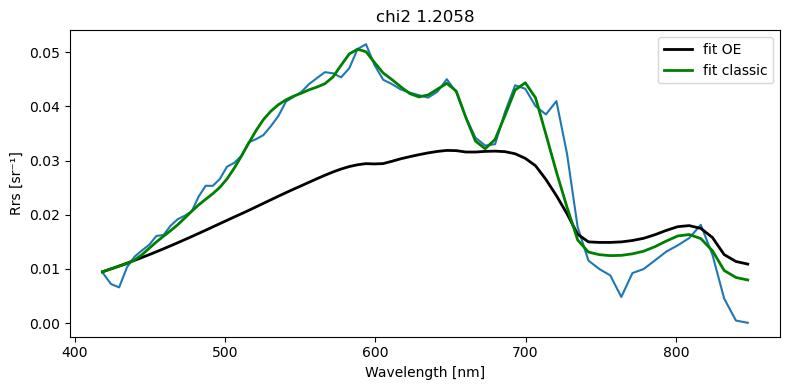

In [62]:
## check fit, plot forward simulations!
# valid = np.where(np.sum(np.logical_not(np.isnan(sp_spectra)), axis=1)>0)[0]
# print(len(valid))
# minchi = sp_results['chi2'][valid] == np.min(sp_results['chi2'][valid])
# i = valid[minchi][0]
# # for i in valid[1:2]:
# print(i)
# vi = 41
# i=valid[vi]

## only valid spectra inverted:
minchi = sp_results['chi2'] == np.min(sp_results['chi2'])
i = np.where(minchi)[0][0]
i = 1
print(i)
vi = i

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wavelengths, sp_spectra[valid,:][i,:])
ax.plot(wavelengths, sp_results['y_hat'][i], 'k-', lw=2, label='fit OE')
ax.plot(invWL, invRrs.iloc[vi,:], 'g-', lw=2, label='fit classic')
ax.set_title('chi2 ' +str(np.round(sp_results['chi2'][i], 4)))
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr⁻¹]')
ax.legend()
plt.tight_layout()
plt.show()

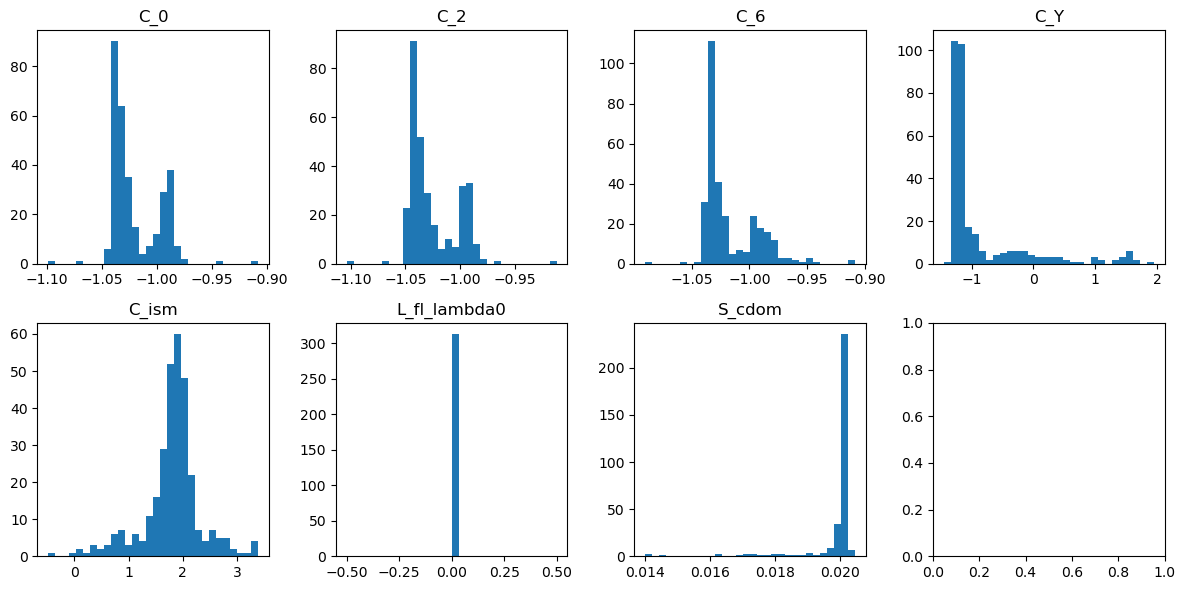

In [29]:
# Overview inversion
Nx, Ny = (4,2)
fig, ax = plt.subplots(Ny, Nx, figsize=(12,6))
ix, iy = (0,0)
for i, key in enumerate(fit_config.keys()):
    if fit_config[key]['log']:
        ax[iy, ix].hist(np.log10(sp_results['x_hat'][valid,i]), 30)
    else:
        ax[iy, ix].hist(sp_results['x_hat'][valid,i], 30)
    ax[iy, ix].set_title(key)
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1
fig.tight_layout()
plt.show()

Median chi2 raw:        1.0164
Median chi2 calibrated: 720.1524  (should be ≈ 1 if noise is well-calibrated)


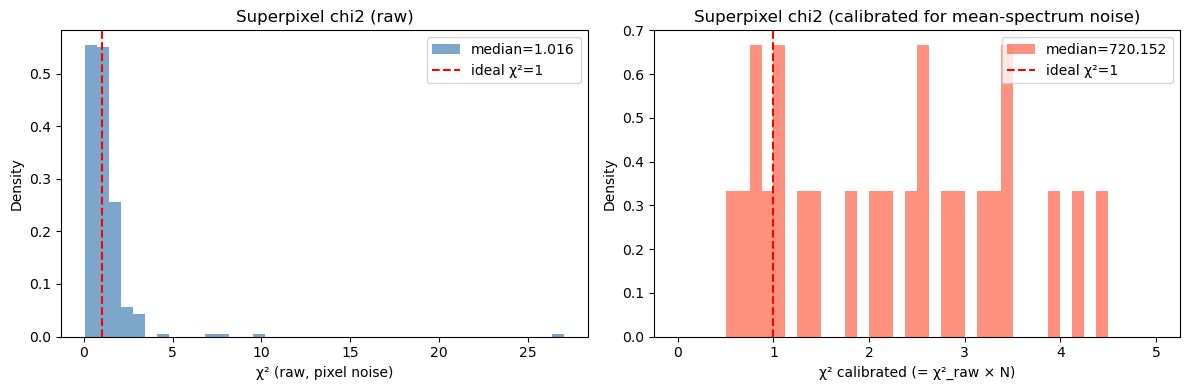

In [54]:
chi2_raw = sp_results['chi2']
chi2_cal = chi2_raw * sp_counts[valid]   # calibrated: chi2 × N

print(f'Median chi2 raw:        {np.nanmedian(chi2_raw):.4f}')
print(f'Median chi2 calibrated: {np.nanmedian(chi2_cal):.4f}  (should be ≈ 1 if noise is well-calibrated)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

kw = dict(bins=40, density=True, alpha=0.7)
axes[0].hist(chi2_raw, **kw, color='steelblue', label=f'median={np.nanmedian(chi2_raw):.3f}')
axes[0].axvline(1.0, color='r', ls='--', lw=1.5, label='ideal χ²=1')
axes[0].set_xlabel('χ² (raw, pixel noise)')
axes[0].set_ylabel('Density')
axes[0].set_title('Superpixel chi2 (raw)')
axes[0].legend()

axes[1].hist(chi2_cal, range=(0, 5), **kw, color='tomato', label=f'median={np.nanmedian(chi2_cal):.3f}')
axes[1].axvline(1.0, color='r', ls='--', lw=1.5, label='ideal χ²=1')
axes[1].set_xlabel('χ² calibrated (= χ²_raw × N)')
axes[1].set_ylabel('Density')
axes[1].set_title('Superpixel chi2 (calibrated for mean-spectrum noise)')
axes[1].legend()

plt.tight_layout()
plt.show()



## Step 4 — Back-interpolation: PCA + kNN IDW

For each pixel, find the k=4 nearest superpixels in 6-component PCA space  
(fitted on brightness-normalised mean spectra), then compute an inverse-distance  
weighted average of their retrieval results.

Uncertainty propagation:
- **Formal**: `σ²_pixel = Σ wᵢ² σ²_spᵢ` — posterior uncertainty propagated through IDW weights
- **Interpolation spread**: `+ Σ wᵢ (x_hat_spᵢ − x_hat_pixel)²` — spread among k neighbours

In [63]:
## Original: OE with Error Propagation ##
k            = 4
n_components = 6

t0 = time.perf_counter()
bp = superpixel_engine.backinterp_pca_knn(
    Rrs_image.reshape(n_pixels, n_obs),
    sp_spectra[valid,:],
    sp_results['x_hat'],
    sp_sigma=sp_results['sigma'],
    sp_A_diag=sp_results['A_diag'],
    k=k, n_components=n_components,
)
t_interp = time.perf_counter() - t0

x_hat_flat  = bp['x_hat']
sigma_flat  = bp['sigma']
A_diag_flat = bp['A_diag']

n_fit   = x_hat_flat.shape[-1]
x_hat_sp  = x_hat_flat.reshape(n_rows, n_cols, n_fit)
sigma_sp  = sigma_flat.reshape(n_rows, n_cols, n_fit)
A_diag_sp = A_diag_flat.reshape(n_rows, n_cols, n_fit)

print(f'Back-interpolation: {t_interp:.2f} s')
print(f'x_hat shape: {x_hat_sp.shape}')

Back-interpolation: 8.07 s
x_hat shape: (930, 1648, 7)


In [65]:
## Full Inversion Classic ##
## from Inversion IOP 
varList = ['C_0', 'C_2', 'C_3', 'C_4', 'C_6', 'C_Y', 'C_ism']
k            = 4
n_components = 6

t0 = time.perf_counter()
bp = superpixel_engine.backinterp_pca_knn(
    Rrs_image.reshape(n_pixels, n_obs),
    sp_spectra[valid,:],
    invIOP[varList].values,
    k=k, n_components=n_components,
)
t_interp = time.perf_counter() - t0

x_hat_flat  = bp['x_hat']
# sigma_flat  = bp['sigma']
# A_diag_flat = bp['A_diag']

n_fit   = x_hat_flat.shape[-1]
x_hat_sp  = x_hat_flat.reshape(n_rows, n_cols, n_fit)
# sigma_sp  = sigma_flat.reshape(n_rows, n_cols, n_fit)
# A_diag_sp = A_diag_flat.reshape(n_rows, n_cols, n_fit)

print(f'Back-interpolation: {t_interp:.2f} s')
print(f'x_hat shape: {x_hat_sp.shape}')

Back-interpolation: 5.72 s
x_hat shape: (930, 1648, 7)


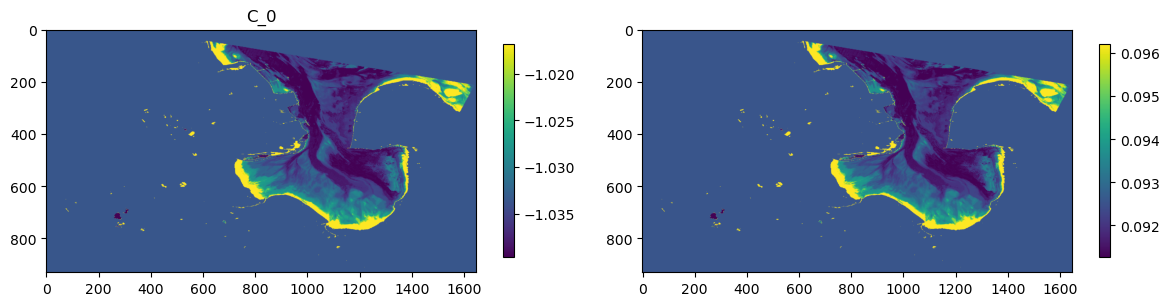

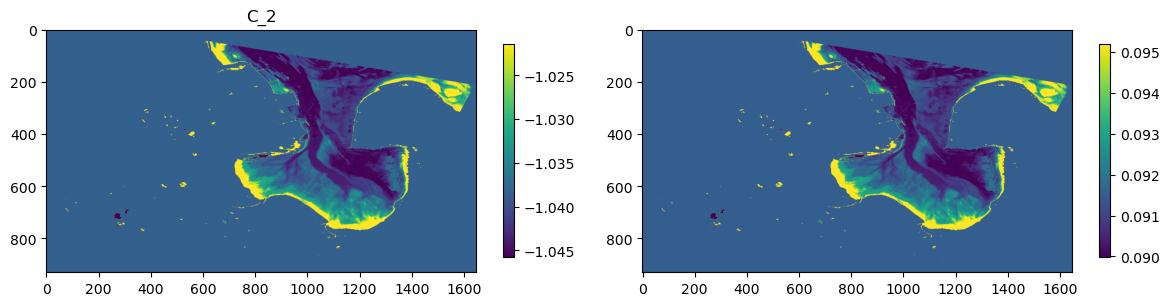

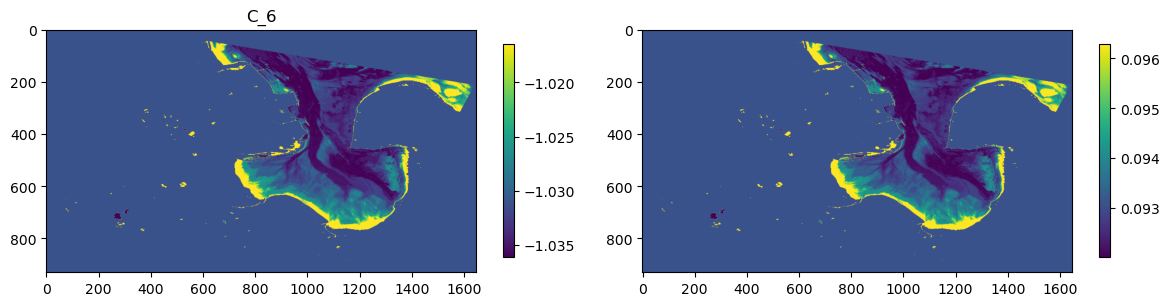

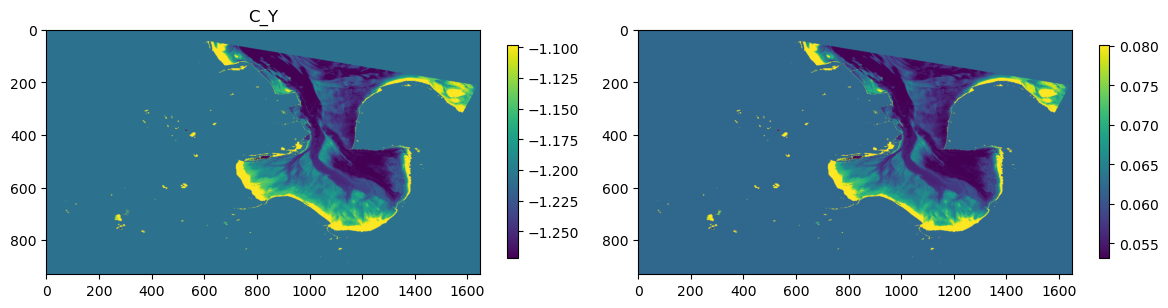

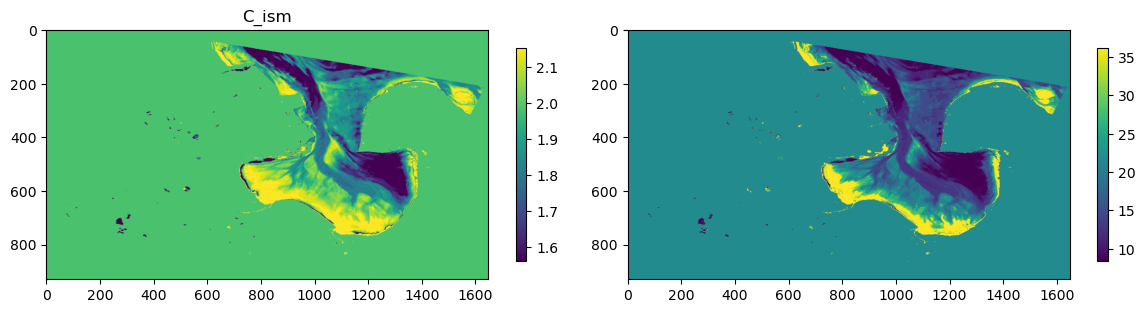

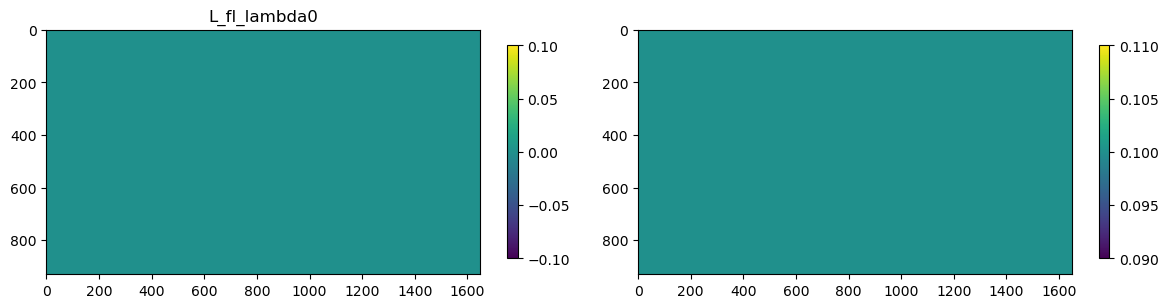

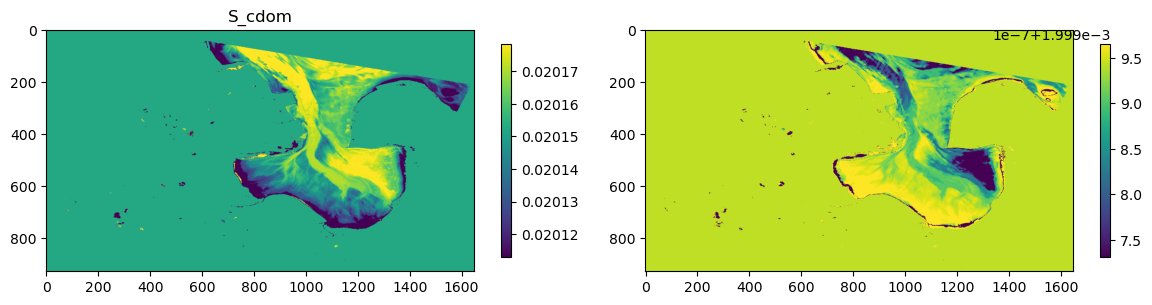

In [64]:
## plot Original with Errors ##
for i, key in enumerate(fit_config.keys()):
    fig, ax = plt.subplots(1, ncols=2, figsize=(12,3))
    px = x_hat_sp[...,i]
    if fit_config[key]['log']:
        vmin, vmax = np.nanpercentile(np.log10(px), [2, 98])
        im = ax[0].imshow(np.log10(px), vmin=vmin, vmax=vmax)
    else:
        vmin, vmax = np.nanpercentile(px, [2, 98])
        im = ax[0].imshow(px, vmin=vmin, vmax=vmax)
    ax[0].set_title(key)
    plt.colorbar(im, ax=ax[0], shrink=0.8)

    sig_px = sigma_sp[...,i]
    vmin, vmax = np.nanpercentile(sig_px, [2, 98])
    im = ax[1].imshow(sig_px, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax[1], shrink=0.8)
    
    fig.tight_layout()
    plt.show()

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_3972\3187077630.py:15: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(np.log10(px), vmin=-1., vmax=np.log10(vmax))


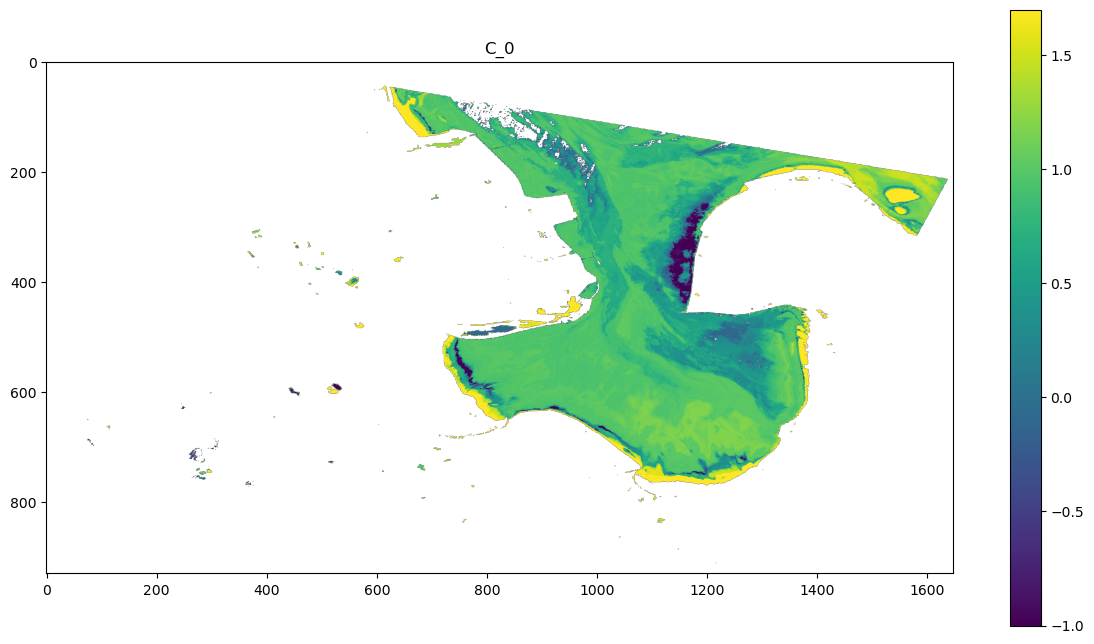

In [74]:
## plot Full Inversion ##
invalidImage = np.sum(np.isnan(Rrs_image), axis=-1)>0
for i, key in enumerate(varList[:1]):
    fig, ax = plt.subplots(1, 1, figsize=(12,8))
    px = x_hat_sp[...,i]
    # px[invalidImage] = np.nan
    
    # if key.startswith('C_'):
    #     vmin, vmax = np.nanpercentile(np.log10(px), [2, 98])
    #     im = ax.imshow(np.log10(px), vmin=vmin, vmax=vmax)
    # else:
    vmin, vmax = np.nanpercentile(px, [2, 98])
    if vmax > 50:
        vmax=50
    im = ax.imshow(np.log10(px), vmin=-1., vmax=np.log10(vmax))
    ax.set_title(key)
    plt.colorbar(im, ax=ax, shrink=0.8)

    # sig_px = sigma_sp[...,i]
    # vmin, vmax = np.nanpercentile(sig_px, [2, 98])
    # im = ax[1].imshow(sig_px, vmin=vmin, vmax=vmax)
    # plt.colorbar(im, ax=ax[1], shrink=0.8)
    
    fig.tight_layout()
    plt.show()

### PCA embedding — superpixels coloured by retrieval

In [65]:
# sp_norm = sp_spectra / np.where(sp_spectra.sum(axis=-1, keepdims=True) == 0, 1.0,
#                                 sp_spectra.sum(axis=-1, keepdims=True))
# sp_norm
valid = np.sum(np.logical_not(np.isnan(sp_spectra)), axis=1)>0
print(len(valid), np.sum(valid))

1125 313


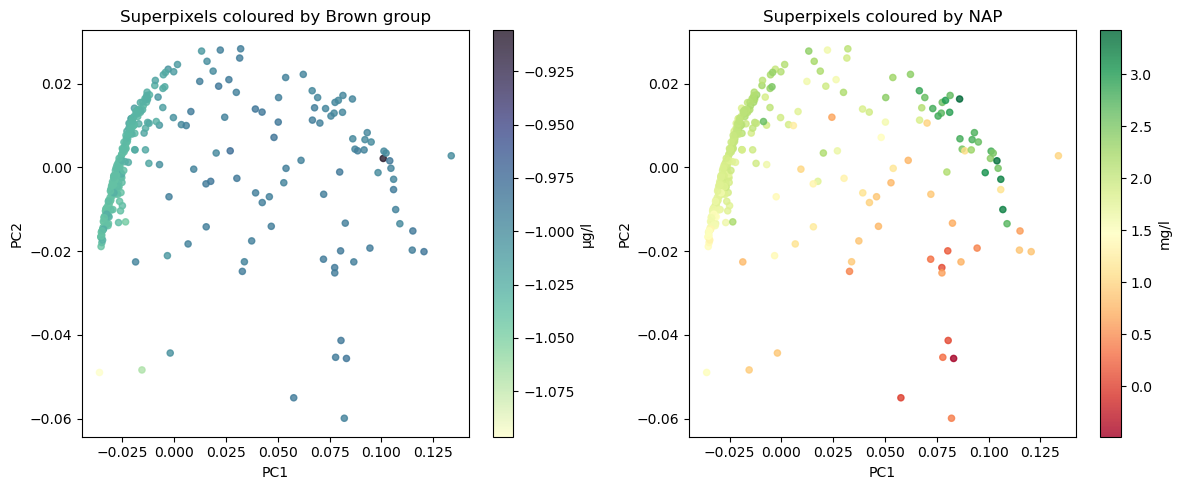

In [69]:
from sklearn.decomposition import PCA
PARAM_META = {
    'C_0':      ('Brown group',          'µg/l',     cm.deep),
    'C_ism': ('NAP',    'mg/l', 'RdYlGn'),
}

sp_norm = sp_spectra[valid] / np.where(sp_spectra[valid].sum(axis=-1, keepdims=True) == 0, 1.0,
                                sp_spectra[valid].sum(axis=-1, keepdims=True))
pca    = PCA(n_components=min(n_components, n_segs_actual - 1, n_obs))
sp_pca = pca.fit_transform(sp_norm)

param_labels = {n: PARAM_META[n] for n in setup.fit_names if n in PARAM_META}
n_params = len(param_labels)

fig, axes = plt.subplots(1, n_params, figsize=(6 * n_params, 5))
axes = np.atleast_1d(axes)

for ax, (param, (label, unit, cmap)) in zip(axes, param_labels.items()):
    i     = setup.fit_names.index(param)
    color = np.log10(sp_results['x_hat'][valid, i])
    sc    = ax.scatter(sp_pca[:, 0], sp_pca[:, 1], c=color, cmap=cmap, s=20, alpha=0.8)
    plt.colorbar(sc, ax=ax, label=unit)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Superpixels coloured by {label}')

plt.tight_layout()
plt.show()

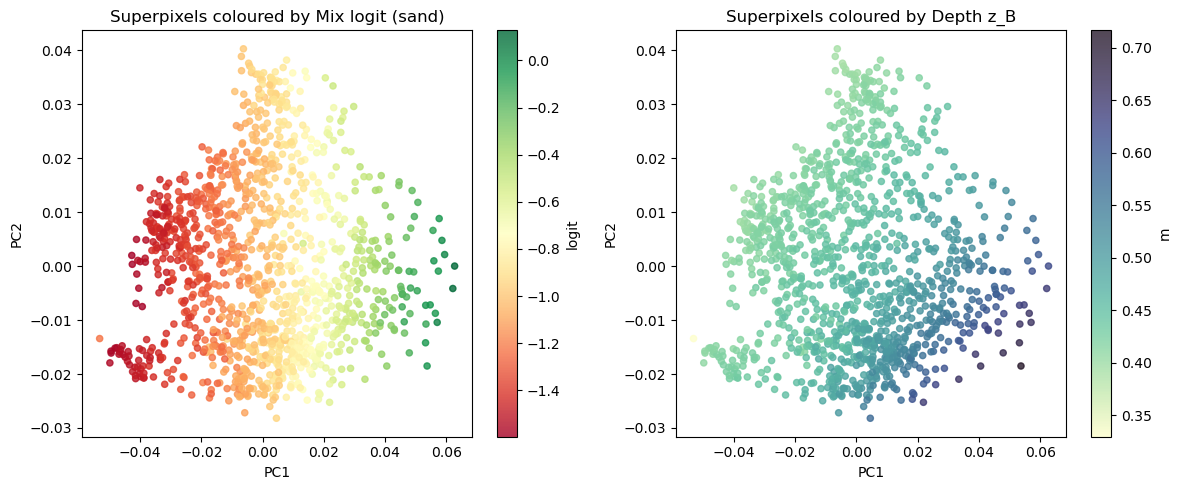

In [10]:
from sklearn.decomposition import PCA

sp_norm = sp_spectra / np.where(sp_spectra.sum(axis=-1, keepdims=True) == 0, 1.0,
                                sp_spectra.sum(axis=-1, keepdims=True))
pca    = PCA(n_components=min(n_components, n_segs_actual - 1, n_obs))
sp_pca = pca.fit_transform(sp_norm)

param_labels = {n: PARAM_META[n] for n in setup.fit_names if n in PARAM_META}
n_params = len(param_labels)

fig, axes = plt.subplots(1, n_params, figsize=(6 * n_params, 5))
axes = np.atleast_1d(axes)

for ax, (param, (label, unit, cmap)) in zip(axes, param_labels.items()):
    i     = setup.fit_names.index(param)
    color = sp_results['x_hat'][:, i]
    sc    = ax.scatter(sp_pca[:, 0], sp_pca[:, 1], c=color, cmap=cmap, s=20, alpha=0.8)
    plt.colorbar(sc, ax=ax, label=unit)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Superpixels coloured by {label}')

plt.tight_layout()
plt.show()

## Maps — superpixel vs per-pixel (NB07b reference)

Run the reference per-pixel inversion for direct comparison.

In [70]:
t0 = time.perf_counter()
results_px = dask_oe_engine.invert_image(
    Rrs_image, setup, noise,
    n_iter=n_iter, tile_size=tile_size,
)
t_px = time.perf_counter() - t0
print(f'Per-pixel inversion: {t_px:.2f} s')

KeyboardInterrupt: 

f_mix_0: RMSD = 0.07088  max|diff| = 0.4311


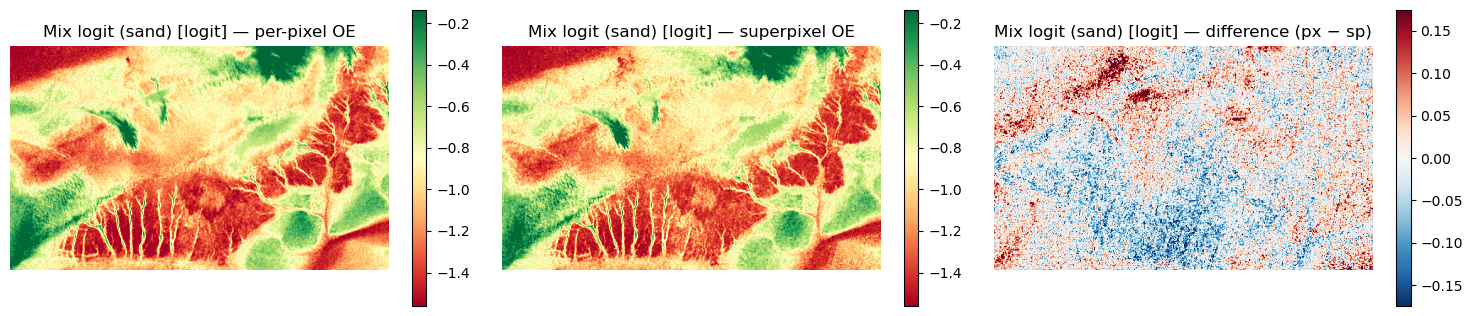

zB: RMSD = 0.01627  max|diff| = 0.2059


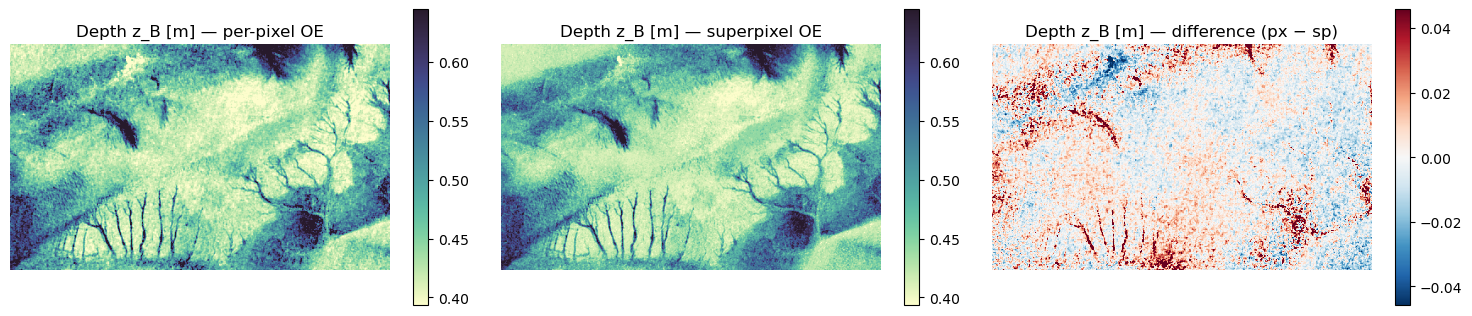

In [12]:
for param, (label, unit, cmap) in param_labels.items():
    i    = setup.fit_names.index(param)
    px   = results_px['x_hat'][..., i]
    sp   = x_hat_sp[..., i]
    diff = px - sp

    vmin, vmax = np.nanpercentile(px, [2, 98])
    dabs = np.nanpercentile(np.abs(diff), 98)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axes[0].imshow(px,   vmin=vmin, vmax=vmax, cmap=cmap, origin='upper')
    im1 = axes[1].imshow(sp,   vmin=vmin, vmax=vmax, cmap=cmap, origin='upper')
    im2 = axes[2].imshow(diff, vmin=-dabs, vmax=dabs, cmap='RdBu_r', origin='upper')

    for ax, im, title in zip(axes, [im0, im1, im2],
                              ['per-pixel OE', 'superpixel OE', 'difference (px − sp)']):
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'{label} [{unit}] — {title}')
        ax.axis('off')

    rmsd = np.sqrt(np.nanmean(diff**2))
    print(f'{param}: RMSD = {rmsd:.4g}  max|diff| = {np.nanmax(np.abs(diff)):.4g}')

    plt.tight_layout()
    plt.show()

f_mix_0: RMSD = 0.07088  max|diff| = 0.4311


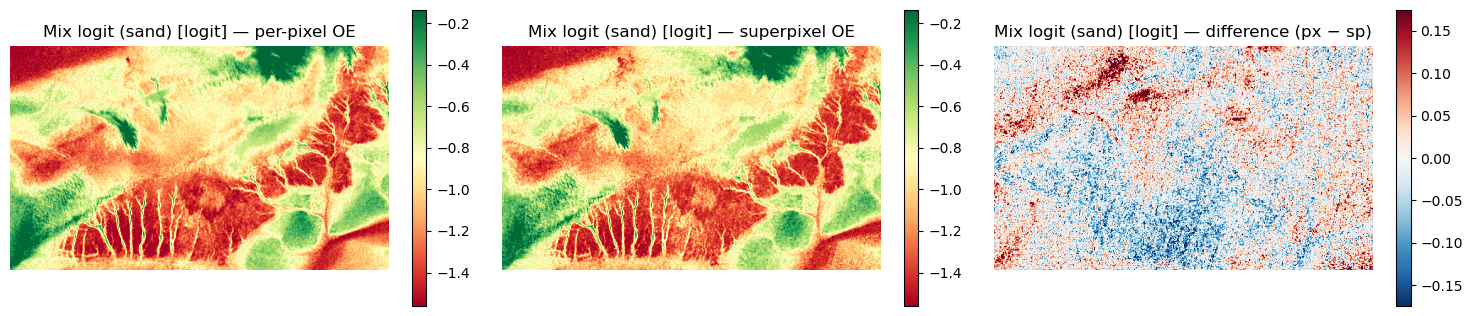

zB: RMSD = 0.01627  max|diff| = 0.2059


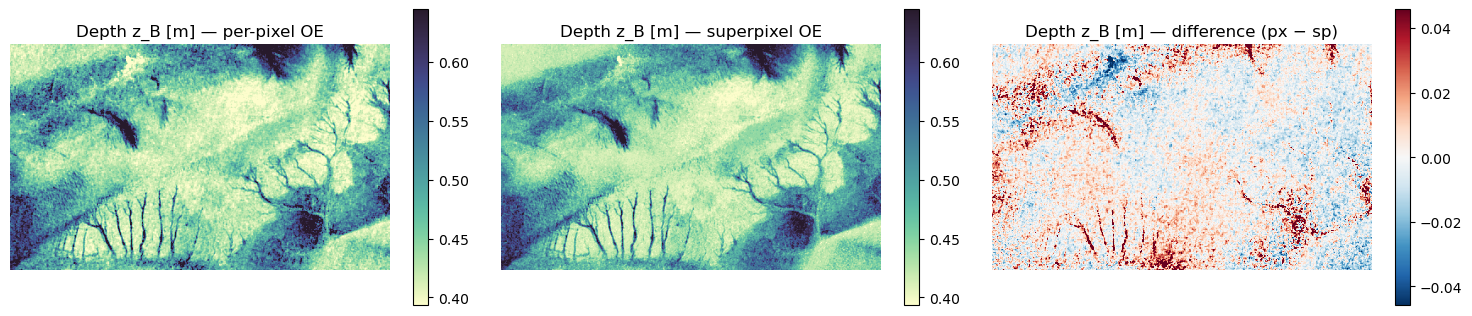

In [12]:
for param, (label, unit, cmap) in param_labels.items():
    i    = setup.fit_names.index(param)
    px   = results_px['x_hat'][..., i]
    sp   = x_hat_sp[..., i]
    diff = px - sp

    vmin, vmax = np.nanpercentile(px, [2, 98])
    dabs = np.nanpercentile(np.abs(diff), 98)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axes[0].imshow(px,   vmin=vmin, vmax=vmax, cmap=cmap, origin='upper')
    im1 = axes[1].imshow(sp,   vmin=vmin, vmax=vmax, cmap=cmap, origin='upper')
    im2 = axes[2].imshow(diff, vmin=-dabs, vmax=dabs, cmap='RdBu_r', origin='upper')

    for ax, im, title in zip(axes, [im0, im1, im2],
                              ['per-pixel OE', 'superpixel OE', 'difference (px − sp)']):
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'{label} [{unit}] — {title}')
        ax.axis('off')

    rmsd = np.sqrt(np.nanmean(diff**2))
    print(f'{param}: RMSD = {rmsd:.4g}  max|diff| = {np.nanmax(np.abs(diff)):.4g}')

    plt.tight_layout()
    plt.show()

## Uncertainty comparison — propagated σ

f_mix_0: median σ  px=0.2630  sp=0.2675


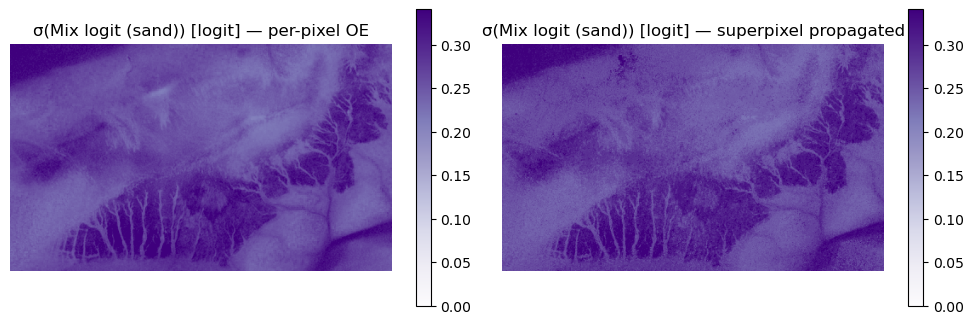

zB: median σ  px=0.0817  sp=0.0816


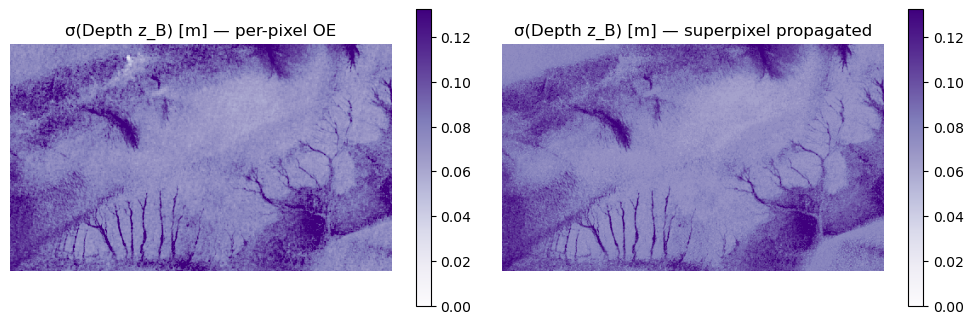

In [13]:
for param, (label, unit, _) in param_labels.items():
    i      = setup.fit_names.index(param)
    sig_px = results_px['sigma'][..., i]
    sig_sp = sigma_sp[..., i]

    vmax = np.nanpercentile(sig_px, 98)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(sig_px, vmin=0, vmax=vmax, cmap='Purples', origin='upper')
    im1 = axes[1].imshow(sig_sp, vmin=0, vmax=vmax, cmap='Purples', origin='upper')
    for ax, im, title in zip(axes, [im0, im1], ['per-pixel OE', 'superpixel propagated']):
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'σ({label}) [{unit}] — {title}')
        ax.axis('off')

    print(f'{param}: median σ  px={np.nanmedian(sig_px):.4f}  sp={np.nanmedian(sig_sp):.4f}')
    plt.tight_layout()
    plt.show()

## Timing summary

In [14]:
t_total_sp = t_seg + t_sp + t_interp

print(f'\n{"Step":<30s} {"Time":>8s}')
print('-' * 40)
print(f'{"SLIC segmentation":<30s} {t_seg:>8.2f} s')
print(f'{"Superpixel OE inversion":<30s} {t_sp:>8.2f} s  ({n_segs_actual} segments)')
print(f'{"PCA + kNN back-interpolation":<30s} {t_interp:>8.2f} s')
print(f'{"Total superpixel pipeline":<30s} {t_total_sp:>8.2f} s')
print(f'{"Per-pixel OE (reference)":<30s} {t_px:>8.2f} s  ({n_pixels} pixels)')
print()
print(f'Speedup: {t_px / t_total_sp:.1f}×  ({n_pixels / n_segs_actual:.0f}× fewer OE inversions)')


Step                               Time
----------------------------------------
SLIC segmentation                  0.26 s
Superpixel OE inversion           35.69 s  (1212 segments)
PCA + kNN back-interpolation       0.89 s
Total superpixel pipeline         36.84 s
Per-pixel OE (reference)         119.42 s  (119883 pixels)

Speedup: 3.2×  (99× fewer OE inversions)


## Quality diagnostics — within-segment variance

Within-segment variance of the back-interpolated x_hat measures how much  
the kNN back-interpolation introduces spatial variability inside each segment.  
Ideal: low within-segment variance (smooth within homogeneous segments),  
higher near spectral edges (where neighbouring segments have different values).

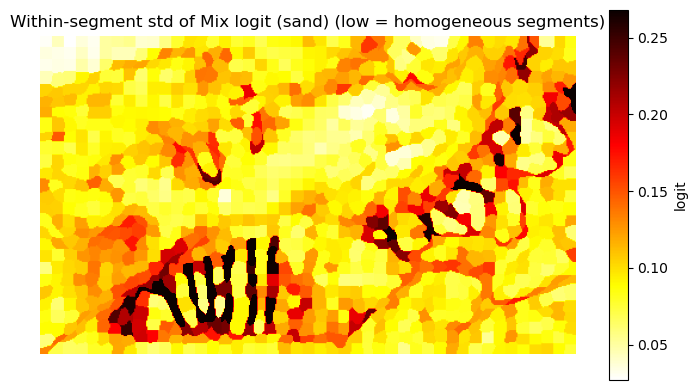

f_mix_0: median within-segment std = 0.0958 logit


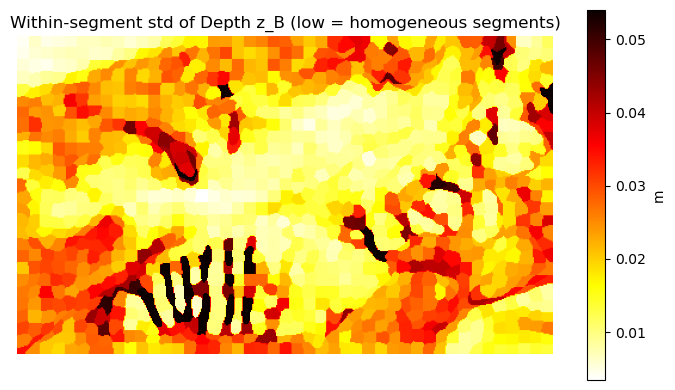

zB: median within-segment std = 0.01892 m


In [15]:
labels_flat = labels.ravel()
seg_ids     = np.unique(labels_flat)

for param, (label, unit, cmap) in param_labels.items():
    i          = setup.fit_names.index(param)
    x_flat     = x_hat_sp[..., i].ravel()
    within_var = np.zeros(n_rows * n_cols)

    for sid in seg_ids:
        mask = labels_flat == sid
        within_var[mask] = x_flat[mask].var()

    within_std = np.sqrt(within_var).reshape(n_rows, n_cols)

    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(within_std, cmap='hot_r', origin='upper',
                   vmax=np.nanpercentile(within_std, 98))
    plt.colorbar(im, ax=ax, label=unit)
    ax.set_title(f'Within-segment std of {label} (low = homogeneous segments)')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f'{param}: median within-segment std = {np.nanmedian(within_std):.4g} {unit}')